# QS-Net: Encoder Lipschitz $L_\varphi$
## UNSW-NB15 | Capped Sample (400) | ~2800 Train | Batch Size 64 | 10 Epochs | LR 0.05
## Target (y) = "label_multiclass" | Data Reupload = 2

## Setup

In [1]:
import pennylane as qp
from pennylane import numpy as np
import torch

import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
import time

In [2]:
from scripts.constants import (
    DEFAULT_LR, DEFAULT_BATCH_SIZE,
    DEFAULT_LAMBDA1, DEFAULT_LAMBDA2, DEFAULT_NOISE_RATE,
    DEFAULT_DELTA,
)
from scripts.data import (
    capped_sample,
    load_split,
    plot_class_balance_pie,
)
from scripts.circuit import build_forward_circuit, create_quantum_device
from scripts.train import train_maqt
from scripts.utils import get_torch_device, to_np_y
from scripts.logging import write_history_log
from scripts.prototypes import prototype_summary
from scripts.inference import estimate_lipschitz

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")

PyTorch version: 2.12.1+cu126
CUDA available?: True
CUDA device name: NVIDIA GeForce GTX 1060
Current CUDA device index: 0


## Load Dataset: UNSW-NB15

In [4]:
NOTEBOOK_NAME = "estimate-lipschitz_unsw-nb15"
dataset = "UNSW-NB15"
split_prefix = "q8"
target_col = "label_multiclass"
data_path = f"data/{dataset}/quantum"

In [5]:
df = pd.read_parquet(f"{data_path}/{split_prefix}_train.parquet")
df

,rate_dst,iat,rate,rate_src,duration,dst_bytes,conn_state,dst_pkts,label_multiclass,label_binary,label_family
0,2.660748,1.000199,1.193106,1.289150,1.240526,2.600926,3.141593,2.190781,Exploits,1,exploits
1,1.300715,1.148865,0.717575,1.401026,0.207269,0.850290,0.374600,0.370983,Normal,0,benign
2,0.000000,0.002482,2.641954,2.489562,0.000007,0.000000,0.168227,0.000000,Generic,1,generic
3,1.547429,1.337109,0.657683,1.161471,0.572600,1.232307,3.141593,0.809729,Normal,0,benign
4,2.342302,0.643438,1.282489,1.506876,0.034630,1.447465,3.141593,0.741966,Normal,0,benign
...,...,...,...,...,...,...,...,...,...,...,...
71089,1.413310,1.351137,0.614096,1.217883,0.610868,1.118026,3.141593,0.741966,Exploits,1,exploits
71090,1.808522,1.157237,0.776405,1.294835,0.348747,1.380490,3.141593,0.741966,DoS,1,dos
71091,2.636567,0.979324,1.179932,1.310244,0.758969,2.410352,3.141593,1.868532,Exploits,1,exploits
71092,1.803881,0.954620,0.931850,1.601995,0.431998,1.412047,3.141593,1.028084,Exploits,1,exploits


In [6]:
# check rows if NaN dropped
df[df[target_col].notna()].copy()

,rate_dst,iat,rate,rate_src,duration,dst_bytes,conn_state,dst_pkts,label_multiclass,label_binary,label_family
0,2.660748,1.000199,1.193106,1.289150,1.240526,2.600926,3.141593,2.190781,Exploits,1,exploits
1,1.300715,1.148865,0.717575,1.401026,0.207269,0.850290,0.374600,0.370983,Normal,0,benign
2,0.000000,0.002482,2.641954,2.489562,0.000007,0.000000,0.168227,0.000000,Generic,1,generic
3,1.547429,1.337109,0.657683,1.161471,0.572600,1.232307,3.141593,0.809729,Normal,0,benign
4,2.342302,0.643438,1.282489,1.506876,0.034630,1.447465,3.141593,0.741966,Normal,0,benign
...,...,...,...,...,...,...,...,...,...,...,...
71089,1.413310,1.351137,0.614096,1.217883,0.610868,1.118026,3.141593,0.741966,Exploits,1,exploits
71090,1.808522,1.157237,0.776405,1.294835,0.348747,1.380490,3.141593,0.741966,DoS,1,dos
71091,2.636567,0.979324,1.179932,1.310244,0.758969,2.410352,3.141593,1.868532,Exploits,1,exploits
71092,1.803881,0.954620,0.931850,1.601995,0.431998,1.412047,3.141593,1.028084,Exploits,1,exploits


In [7]:
# get labels
class_names = sorted(df[target_col].dropna().unique())
class_names

['Analysis',
 'Backdoor',
 'DoS',
 'Exploits',
 'Fuzzers',
 'Generic',
 'Normal',
 'Reconnaissance']

In [8]:
# load all data
X_train_full, y_train_full = load_split(data_path, f"{split_prefix}_train", target_col, class_names)

In [9]:
# check shape
[X_train_full.shape, y_train_full.shape]

[(71094, 8), (71094,)]

## EDA (Before Subset)

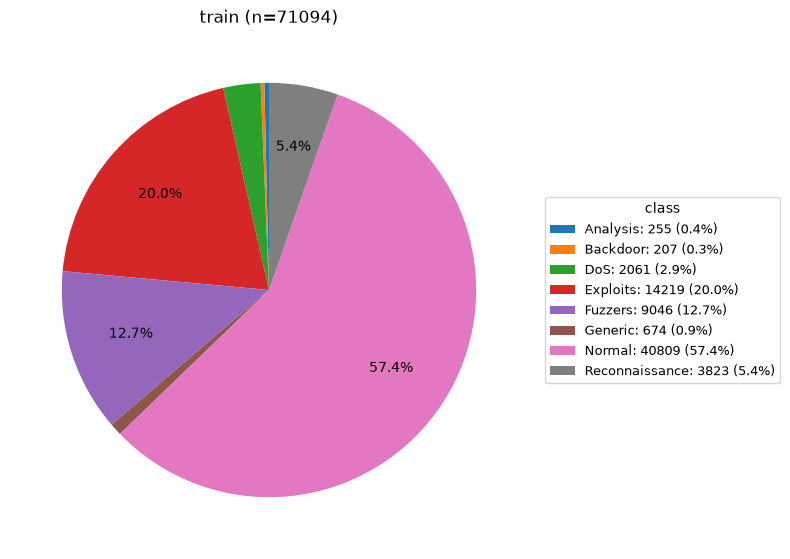

In [10]:
# pie chart
fig, ax = plt.subplots(figsize=(8, 8))

plot_class_balance_pie(
    y_train_full, class_names,
    title=f"train (n={len(to_np_y(y_train_full))})",
    ax=ax,
)

plt.tight_layout()
plt.show()

## Data Subset

In [11]:
SUBSET = True  # set to False for the full dataset
SEED = 42
PER_CLASS_CAP = 400

In [12]:
if SUBSET is True:
    X_train, y_train = capped_sample(X_train_full, y_train_full, PER_CLASS_CAP, seed=SEED)
else:
    X_train, y_train = X_train_full, y_train_full

# check shape
[X_train.shape, y_train.shape]

[(2862, 8), (2862,)]

## EDA (After Subset)

In [13]:
num_classes = len(class_names)
num_qubits = X_train.shape[1]

print(f"number of classes: {num_classes}")
print(f"number of qubits: {num_qubits}")

number of classes: 8
number of qubits: 8


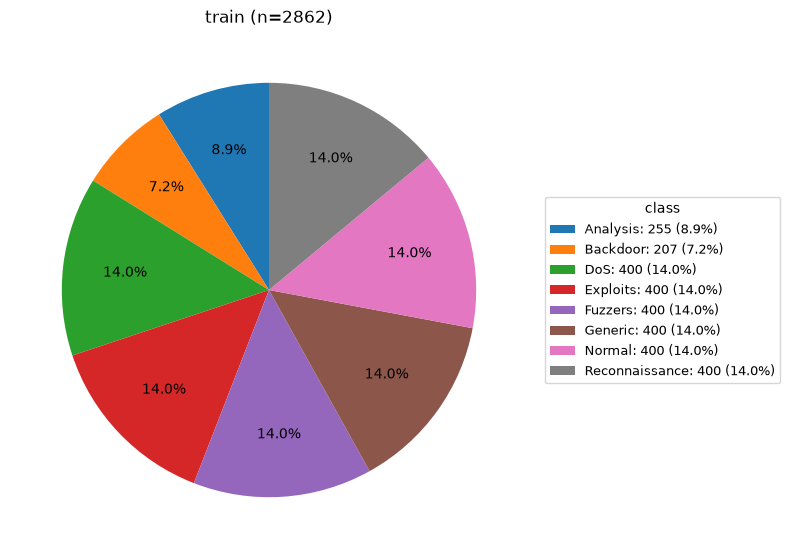

In [14]:
# pie chart
fig, ax = plt.subplots(figsize=(8, 8))

plot_class_balance_pie(
    y_train, class_names,
    title=f"train (n={len(to_np_y(y_train))})",
    ax=ax,
)

plt.tight_layout()
plt.show()

## Quantum Circuit: Angle Encoding, Data Reuploading, and Adding Noise

$x\xrightarrow[\text{encode}]{\phi(x)}\ket{\psi(x)}\xrightarrow[\text{variational}]{U(\theta)}\ket{\Phi(x)}\xrightarrow{\Lambda_p}\rho(x)$
- $x$: classical data
- $\phi(x)$: `qp.AngleEmbedding()`
- $\ket{\psi(x)}$: quantum state after encoding
- $U(\theta)$: `qp.StronglyEntanglingLayers()`
- $\ket{\Phi(x)}$: quantum state after variational transform
- $\rho(x)=\Lambda_p(\ket{\Phi(x)}\bra{\Phi(x)})$: standard depolarization channel to model NISQ noise


In [15]:
num_layers = 2                  # reupload same classical data
noise_rate = DEFAULT_NOISE_RATE

In [16]:
# initialize devices
device = get_torch_device()
dev = create_quantum_device(num_qubits) # or dev = qp.device("default.mixed", wires=num_qubits)

# define circuit
forward_circuit = build_forward_circuit(dev, num_qubits, num_layers, noise_rate=noise_rate)

## Training

Minimizing:
- $L_{CE}$ adjusts $\theta$ for better class predictions.
- $L_{intra}$ pulls each sample toward its class prototype
- $L_{inter}$ pushs different-class prototypes apart (maximize trace distance)

Day 16 trains a fresh $\theta^\star$ with the same protocol on every dataset (`capped_sample` + weighted sampler + 10 epochs), then estimates $L_\varphi$.


In [17]:
epochs = 10
batch_size = DEFAULT_BATCH_SIZE
lr = DEFAULT_LR
lambda1 = DEFAULT_LAMBDA1
lambda2 = DEFAULT_LAMBDA2

In [18]:
theta, head, prototypes, ema_protos, history = train_maqt(
    X_train, y_train,
    n_classes=num_classes,
    n_qubits=num_qubits,
    n_layers=num_layers,
    forward_circuit=forward_circuit,
    device=device,
    epochs=epochs,
    lr=lr,
    batch_size=batch_size,
    lambda1_max=lambda1,
    lambda2_max=lambda2,
    use_weighted_sampler=True,
)

theta_star = theta
print(f"trained encoder: theta shape={tuple(theta_star.shape)} | prototypes={len(prototypes)}")

epoch  1/10 | loss 1.9774 | L_CE 1.9774 | L_intra 0.4282 | L_inter -0.3394 | grad_var 2.14e-04 | intra_fid 0.572 | inter_TD 0.349 | time 598.1s
epoch  2/10 | loss 1.8878 | L_CE 1.8445 | L_intra 0.3852 | L_inter -0.3532 | grad_var 9.16e-04 | intra_fid 0.615 | inter_TD 0.363 | time 607.1s
epoch  3/10 | loss 1.8823 | L_CE 1.7977 | L_intra 0.3803 | L_inter -0.3518 | grad_var 2.63e-03 | intra_fid 0.620 | inter_TD 0.366 | time 606.9s
epoch  4/10 | loss 1.8437 | L_CE 1.7669 | L_intra 0.3667 | L_inter -0.3552 | grad_var 3.30e-03 | intra_fid 0.633 | inter_TD 0.347 | time 606.8s
epoch  5/10 | loss 1.8204 | L_CE 1.7407 | L_intra 0.3647 | L_inter -0.3422 | grad_var 3.73e-03 | intra_fid 0.635 | inter_TD 0.340 | time 608.1s
epoch  6/10 | loss 1.8263 | L_CE 1.7396 | L_intra 0.3756 | L_inter -0.3370 | grad_var 3.89e-03 | intra_fid 0.624 | inter_TD 0.360 | time 606.6s
epoch  7/10 | loss 1.7661 | L_CE 1.6855 | L_intra 0.3764 | L_inter -0.3585 | grad_var 4.33e-03 | intra_fid 0.624 | inter_TD 0.353 | time

## Algo 3: Unified Inference with Disentangled Rejection

At test time, one pass produces either
- a class label with a certified robustness radius $\rightarrow$ `(label, certified_radius)`, or
- a zero-day flag $\rightarrow$ `(ZERO_DAY, 0)`.

The certified radius uses the encoder Lipschitz constant $L_\varphi$:
$$
R = \frac{m}{2(1-p)\,L_\varphi\,C_f}.
$$

## $L_\varphi$ Estimator

For probe points $x$ and Gaussian input perturbations of scale $\delta$:
$$
\hat L_\varphi
= \mathrm{Percentile}_{95}
\left\{
\frac{D_{\mathrm{tr}}\big(\rho(x),\,\rho(x+\delta\xi)\big)}{\delta}
\right\}.
$$

Tuning knobs: `n_probe`, `delta`, `percentile`.


In [19]:
# L_phi tuning knobs
n_probe = 128                 # larger than DEFAULT_N_PROBE (=30) for a stabler distribution
delta = DEFAULT_DELTA         # DEFAULT_DELTA = 0.05
percentile = 95.0
seed = SEED

torch.manual_seed(seed)
np.random.seed(seed)

In [20]:
# estimate Lipschitz constant (95th percentile + full ratio distribution)
L_phi, ratios = estimate_lipschitz(
    X_train,
    theta_star,
    forward_circuit,
    n_probe=n_probe,
    delta=delta,
    device=device,
    percentile=percentile,
    return_ratios=True,
)

L_phi_max = float(np.max(ratios))
L_phi_mean = float(np.mean(ratios))
L_phi_median = float(np.median(ratios))

print(f"dataset           : {dataset}")
print(f"n_probe / delta   : {len(ratios)} / {delta}")
print(f"L_phi (p{percentile:g})   : {L_phi:.4f}   <- Day-16 estimator")
print(f"L_phi (max)       : {L_phi_max:.4f}   <- legacy estimate_lipschitz default")
print(f"L_phi (mean/med)  : {L_phi_mean:.4f} / {L_phi_median:.4f}")

dataset           : UNSW-NB15
n_probe / delta   : 128 / 0.05
L_phi (p95)   : 2.7609   <- Day-16 estimator
L_phi (max)       : 3.1057   <- legacy estimate_lipschitz default
L_phi (mean/med)  : 1.8683 / 1.9199


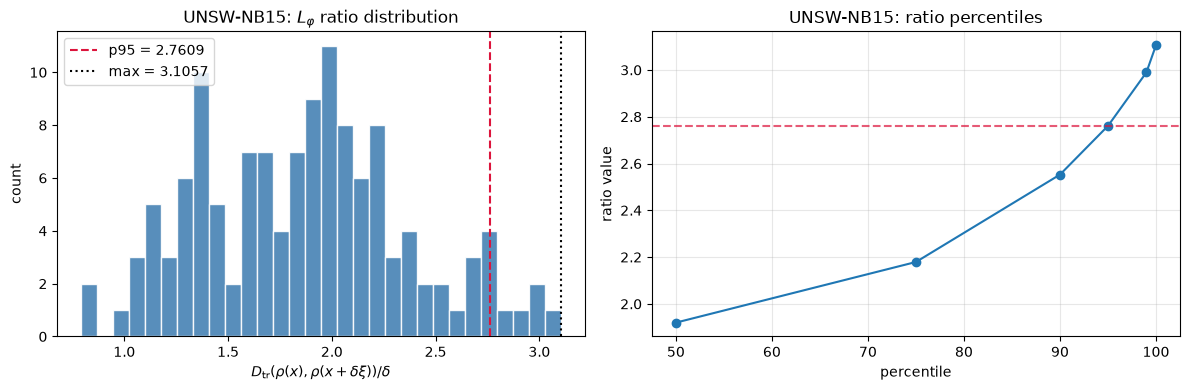

In [21]:
# plot L_phi with its distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ratios, bins=30, color="steelblue", edgecolor="white", alpha=0.9)
axes[0].axvline(L_phi, color="crimson", linestyle="--", label=f"p{percentile:g} = {L_phi:.4f}")
axes[0].axvline(L_phi_max, color="black", linestyle=":", label=f"max = {L_phi_max:.4f}")
axes[0].set_xlabel(r"$D_{\mathrm{tr}}(\rho(x),\rho(x+\delta\xi))/\delta$")
axes[0].set_ylabel("count")
axes[0].set_title(rf"{dataset}: $L_\varphi$ ratio distribution")
axes[0].legend()

q = np.percentile(ratios, [50, 75, 90, 95, 99, 100])
axes[1].plot([50, 75, 90, 95, 99, 100], q, marker="o")
axes[1].axhline(L_phi, color="crimson", linestyle="--", alpha=0.7)
axes[1].set_xlabel("percentile")
axes[1].set_ylabel("ratio value")
axes[1].set_title(rf"{dataset}: ratio percentiles")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
ratio_df = pd.DataFrame({
    "stat": ["n_probe", "delta", "p50", "p75", "p90", "p95", "p99", "max", "mean"],
    "value": [
        len(ratios), delta,
        float(np.percentile(ratios, 50)),
        float(np.percentile(ratios, 75)),
        float(np.percentile(ratios, 90)),
        float(np.percentile(ratios, 95)),
        float(np.percentile(ratios, 99)),
        L_phi_max,
        L_phi_mean,
    ],
})
ratio_df

,stat,value
0,n_probe,128.000000
1,delta,0.050000
2,p50,1.919909
3,p75,2.179071
4,p90,2.552605
5,p95,2.760896
6,p99,2.989414
7,max,3.105735
8,mean,1.868307


In [23]:
# light sweep over (n_probe, delta) for tuning (optional)
SWEEP = True
sweep_rows = []

if SWEEP:
    for n_p in [32, 64, 128]:
        for d in [0.01, 0.05, 0.10]:
            torch.manual_seed(seed)
            np.random.seed(seed)
            Lp, r = estimate_lipschitz(
                X_train, theta_star, forward_circuit,
                n_probe=n_p, delta=d, device=device,
                percentile=percentile, return_ratios=True,
            )
            sweep_rows.append({
                "n_probe": n_p,
                "delta": d,
                "L_phi_p95": Lp,
                "L_phi_max": float(np.max(r)),
                "L_phi_mean": float(np.mean(r)),
            })
    sweep_df = pd.DataFrame(sweep_rows)
else:
    sweep_df = pd.DataFrame()

sweep_df

,n_probe,delta,L_phi_p95,L_phi_max,L_phi_mean
0,32,0.01,2.255125,2.777389,1.693615
1,32,0.05,2.239531,2.756516,1.688865
2,32,0.10,2.207601,2.707561,1.676534
3,64,0.01,2.464388,2.777389,1.767680
4,64,0.05,2.465811,2.756516,1.764412
5,64,0.10,2.451167,2.707561,1.752951
6,128,0.01,2.776853,3.116683,1.872464
7,128,0.05,2.760896,3.105735,1.868307
8,128,0.10,2.718453,3.059057,1.854340


## Logging


In [24]:
# save encoder checkpoint + L_phi artifact
out_dir = Path("models/prototypes") / dataset
out_dir.mkdir(parents=True, exist_ok=True)

ckpt_path = out_dir / f"{NOTEBOOK_NAME}-checkpoint.pt"
torch.save(
    {
        "theta": theta_star.detach().cpu(),
        "head_state_dict": head.state_dict(),
        "prototypes": {k: v.detach().cpu() for k, v in prototypes.items()},
        
        # minimal rebuild / inference meta
        "class_names": list(class_names),
        "num_classes": num_classes,
        "num_qubits": num_qubits,
        "num_layers": num_layers,
        "noise_rate": noise_rate,        
    },
    ckpt_path,
)

artifact = {
    "L_phi": float(L_phi),
    "L_phi_percentile": float(percentile),
    "L_phi_max": float(L_phi_max),
    "L_phi_mean": float(L_phi_mean),
    "L_phi_median": float(L_phi_median),
    "ratios": ratios.tolist(),
    "n_probe": int(len(ratios)),
    "delta": float(delta),
    "sweep": sweep_rows if SWEEP else [],
}

lphi_path = out_dir / f"{NOTEBOOK_NAME}-lphi.pt"
torch.save(artifact, lphi_path)
print("published checkpoint:", ckpt_path.resolve())
print("published L_phi:     ", lphi_path.resolve())

published checkpoint: /home/lawun330/Desktop/quantum-sentinel/models/prototypes/UNSW-NB15/estimate-lipschitz_unsw-nb15-checkpoint.pt
published L_phi:      /home/lawun330/Desktop/quantum-sentinel/models/prototypes/UNSW-NB15/estimate-lipschitz_unsw-nb15-lphi.pt


In [25]:
# write log (final)
log_path = write_history_log(
    history,
    NOTEBOOK_NAME,
    extra={
        ## data
        "data_path": data_path,
        "dataset": dataset,
        "split_prefix": split_prefix,
        "target_col": target_col,
        "n_train": len(X_train),
        "per_class_cap": PER_CLASS_CAP if SUBSET else None,
        "class_names": list(class_names),

        ## algo 1: MAQT train
        "epochs": epochs,
        "batch_size": batch_size,
        "lr": lr,
        "lambda1": lambda1,
        "lambda2": lambda2,
        "use_weighted_sampler": True,

        ## quantum model
        "noise_rate": noise_rate,
        "num_layers": num_layers,
        "num_qubits": num_qubits,
        "num_classes": num_classes,

        ## L_phi estimator
        "L_phi": float(L_phi),
        "L_phi_percentile": float(percentile),
        "L_phi_max": float(L_phi_max),
        "L_phi_mean": float(L_phi_mean),
        "n_probe": int(len(ratios)),
        "delta": float(delta),
        "checkpoint": str(ckpt_path),
    },
    log_dir="logs",
)
print(f"wrote {log_path.resolve()}")

wrote /home/lawun330/Desktop/quantum-sentinel/logs/estimate-lipschitz_unsw-nb15.log
